# Ensemble ENSO Violin Plots

- **Filled violins**: ensemble-mean z (averaged across 50 properly aligned runs, 1200 test-set timesteps)
- **Magenta outline**: single reference run (seed-1, all 6000 timesteps)

In [1]:
# import packages
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

## 1. Ensemble mean (1200 test-set timesteps)

In [2]:
ONI_PATH = 'oni_e3sm_0402.nc'

# ensemble mean z — 1200 test-set timesteps, already aligned
ds_ens     = xr.open_dataset('latent_representations_ensemble_mean_0729.nc')
z_ens      = ds_ens['z_mean'].values

# match ONI labels to the test-set times in the nc file
oni_e3sm   = xr.open_dataset(ONI_PATH)
test_times = ds_ens['time'].values
oni_subset = oni_e3sm.sel(time=test_times)
enso_ens   = oni_subset['enso_phase'].values

print(f'Ensemble z shape:   {z_ens.shape}')
print(f'ENSO labels shape:  {enso_ens.shape}')
print(f'Unique phases:      {np.unique(enso_ens)}')

Ensemble z shape:   (1200, 20)
ENSO labels shape:  (1200,)
Unique phases:      ['El Niño' 'La Niña' 'Neutral']


In [3]:
# enso labels
EL_NINO = 'El Niño'
LA_NINA = 'La Niña'

# create dataframe and melt
df_ens = pd.DataFrame(z_ens, columns=range(20))
df_ens['ENSO Phase'] = enso_ens
df_ens = df_ens[(df_ens['ENSO Phase'] == EL_NINO) | (df_ens['ENSO Phase'] == LA_NINA)]

ds_melt = df_ens.melt(id_vars='ENSO Phase',
                      var_name='Latent Dimension',
                      value_name='Value')

# check number of phases for the 1200 timesteps
print(f'El Niño: {(df_ens["ENSO Phase"] == EL_NINO).sum()}  |  La Niña: {(df_ens["ENSO Phase"] == LA_NINA).sum()}')

El Niño: 171  |  La Niña: 168


## 2. Single reference run (6000 timesteps, for magenta outline)

In [4]:
# single reference run — integer time indices 0-5999, pairs directly with ONI by position
ds_ref  = xr.open_dataset('latent_representations_zmean_0306_final.nc')
z_ref   = ds_ref['z_mean'].values
enso_ref = oni_e3sm['enso_phase'].values

# print shapes
print(f'Reference z shape:  {z_ref.shape}')
print(f'ONI full shape:     {enso_ref.shape}')

# create dataframe and melt again
df_ref = pd.DataFrame(z_ref, columns=range(20))
df_ref['ENSO Phase'] = enso_ref
df_ref = df_ref[(df_ref['ENSO Phase'] == EL_NINO) | (df_ref['ENSO Phase'] == LA_NINA)]

ref_melt = df_ref.melt(id_vars='ENSO Phase',
                       var_name='Latent Dimension',
                       value_name='Value')

# check number of phases for the 6000 timesteps
print(f'El Niño: {(df_ref["ENSO Phase"] == EL_NINO).sum()}  |  La Niña: {(df_ref["ENSO Phase"] == LA_NINA).sum()}')

Reference z shape:  (6000, 20)
ONI full shape:     (6000,)
El Niño: 831  |  La Niña: 819


## 3. Split violin plot

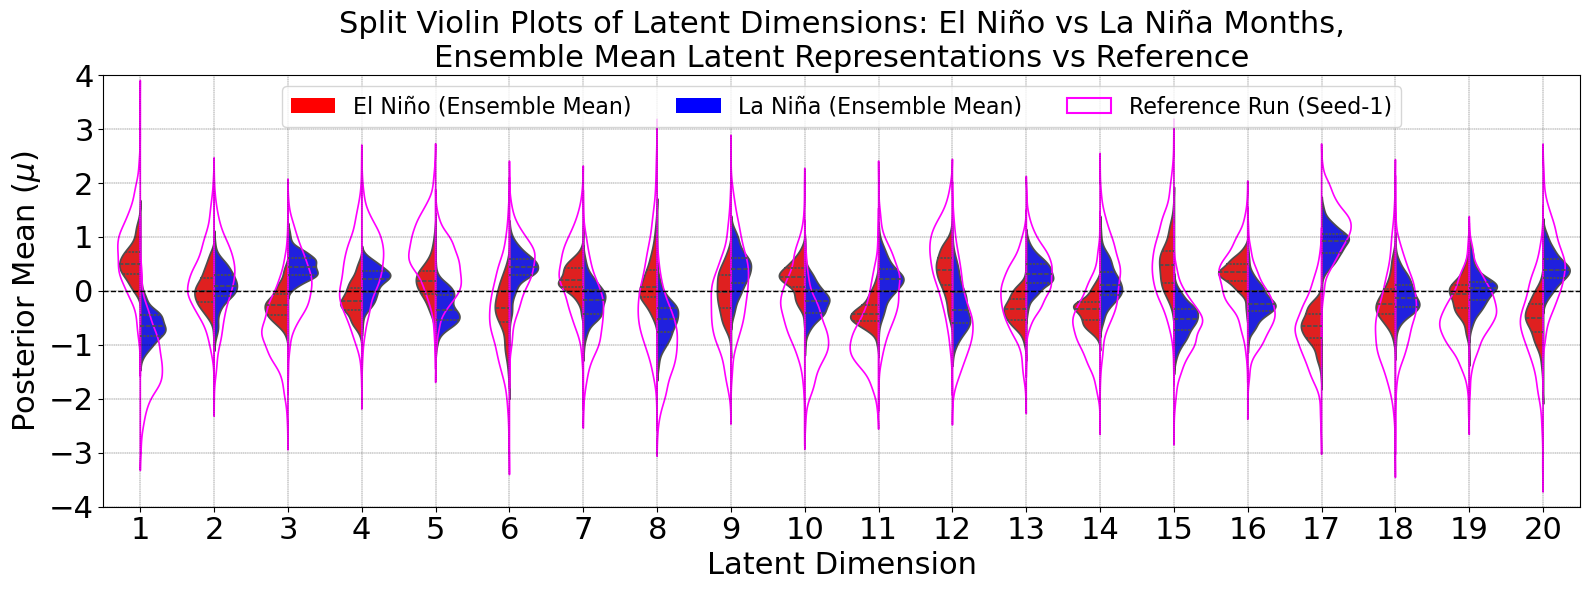

In [6]:
fig, ax = plt.subplots(figsize=(16, 6))

# ensemble mean violins (filled)
sns.violinplot(
    data=ds_melt,
    x='Latent Dimension', y='Value', hue='ENSO Phase',
    split=True,
    hue_order=[EL_NINO, LA_NINA],
    palette={EL_NINO: 'red', LA_NINA: 'blue'},
    inner='quartile',
    ax=ax
)

# reference run (outline only, magenta)
sns.violinplot(
    data=ref_melt,
    x='Latent Dimension', y='Value', hue='ENSO Phase',
    split=True,
    hue_order=[EL_NINO, LA_NINA],
    palette={EL_NINO: 'magenta', LA_NINA: 'magenta'},
    inner=None,
    ax=ax
)
# reference violins outline-only
for collection in ax.collections[-40:]:
    collection.set_facecolor('none')
    collection.set_edgecolor('magenta')
    collection.set_linewidth(1.2)

# formatting items
ax.legend(handles=[
    mpatches.Patch(facecolor='red',  label=f'{EL_NINO} (Ensemble Mean)'),
    mpatches.Patch(facecolor='blue', label=f'{LA_NINA} (Ensemble Mean)'),
    mpatches.Patch(facecolor='none', edgecolor='magenta', linewidth=1.5,
                   label='Reference Run (Seed-1)'),
], fontsize=16, ncol=3, loc='upper center')

ax.axhline(y=0, color='black', linestyle='--', lw=1)
ax.set_xticks(range(20))
ax.set_xticklabels(range(1, 21), fontsize=22)
ax.tick_params(axis='y', labelsize=22)
ax.set_xlabel('Latent Dimension', fontsize=22)
ax.set_ylabel(r'Posterior Mean ($\mu$)', fontsize=22)
ax.set_title(
    'Split Violin Plots of Latent Dimensions: El Niño vs La Niña Months,\n'
    'Ensemble Mean Latent Representations vs Reference',
    fontsize=22
)
ax.set_ylim(-4, 4)
ax.set_yticks(range(-4, 5))
ax.grid(True, linestyle='--', color='k', lw=0.25)
plt.tight_layout()
plt.savefig('violinplots_mu_ensmean_0801.pdf', bbox_inches='tight')
plt.show()